# Fig. 3 — non-equilibrium pulse labeling for a two-foldon model

Two-foldon, three-basin cascade $\mathrm{UU}\!\to\!\mathrm{FU}\!\to\!\mathrm{FF}$. The right column shows the post-pulse uptake envelopes with back exchange applied at the pattern level.

In [22]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

_here = os.getcwd()
_py = os.path.abspath(os.path.join(_here, '..', 'python'))
if _py not in sys.path:
    sys.path.insert(0, _py)

import hdx_env as H
from hdx_env import MetastableBasins, COLORS
H.set_plot_style(use_tex=False)

PLOTS_DIR = os.path.abspath(os.path.join(_here, '..', 'figures'))
os.makedirs(PLOTS_DIR, exist_ok=True)

In [23]:
rng = np.random.default_rng(20260520)

# ---------------------------------------------------------------------------
# Peptide: 8 residues split into foldon A (1-4) and foldon B (6-5)
# ---------------------------------------------------------------------------
N        = 8
P_pep    = tuple(range(N))
foldon_A = list(range(0, 4))    # residues 1..4 (0-indexed: 0..4)
foldon_B = list(range(4, 8))    # residues 5..8 (0-indexed: 5..7)

# Intrinsic exchange rates (high-pH pulse)
k_int    = 10.0 ** rng.uniform(1.2, 3.2, N)         

# Per-basin per-residue open probabilities  (basin 0=UU, 1=FU, 2=FF)
pi_UU = rng.uniform(0.95, 1, N)                                # unfolded
pi_FU_A = 10.0 ** rng.uniform(-4.0, -2.0, len(foldon_A))   # A protected
pi_FU_B = rng.uniform(0.95, 1, len(foldon_B))            # B still exposed
pi_FF_A = 10.0 ** rng.uniform(-4.0, -2.0, len(foldon_A))   # A still protected
pi_FF_B = 10.0 ** rng.uniform(-4.0, -2.0, len(foldon_B))   # B protected

pi_open = np.zeros((3, N))
pi_open[0, :] = pi_UU
pi_open[1, foldon_A] = pi_FU_A
pi_open[1, foldon_B] = pi_FU_B
pi_open[2, foldon_A] = pi_FF_A
pi_open[2, foldon_B] = pi_FF_B

# Basin rates (cooperative cascade UU -> FU -> FF)
k_fA, k_uA = 1,  0.01            # A folds first   (k_f^A / k_u^A = 100)
k_fB, k_uB = 0.02,  0.001            # B follows fast  (k_f^B / k_u^B = 100)

# W_basin[i, j] = rate i -> j  (i != j); diagonal ignored.
W_basin = np.array([
    [0.0,  k_fA, 0.0],     # UU -> ?
    [k_uA, 0.0,  k_fB],    # FU -> ?
    [0.0,  k_uB, 0.0],     # FF -> ?
])
L_basin = W_basin - np.diag(W_basin.sum(axis=1))

# Equilibrium basin populations (detailed balance along the cascade)
p_eq = np.array([1.0, k_fA / k_uA, (k_fA / k_uA) * (k_fB / k_uB)])
p_eq /= p_eq.sum()

print(f'N = {N}    foldon A: residues {[i+1 for i in foldon_A]}')
print(f'           foldon B: residues {[i+1 for i in foldon_B]}')
print(f'k_int range = [{k_int.min():.1f}, {k_int.max():.1f}] /s')
print(f'basin rates: k_f^A={k_fA}, k_u^A={k_uA}, k_f^B={k_fB}, k_u^B={k_uB}')
print(f'p_eq = {p_eq.round(4)}      (UU, FU, FF)')

N = 8    foldon A: residues [1, 2, 3, 4]
           foldon B: residues [5, 6, 7, 8]
k_int range = [18.3, 1405.6] /s
basin rates: k_f^A=1, k_u^A=0.01, k_f^B=0.02, k_u^B=0.001
p_eq = [5.000e-04 4.760e-02 9.519e-01]      (UU, FU, FF)


In [24]:
tau_P = 1e-2                                      # 10 ms pulse
t_Q   = np.logspace(-2, 3, 80)                    # quench-delay grid
p0    = np.array([1.0, 0.0, 0.0])                 # fully unfolded at t = 0

# Basin populations during refolding (no exchange)
p_tQ = np.zeros((len(t_Q), 3))
for ti, tq in enumerate(t_Q):
    p_tQ[ti] = p0 @ expm(L_basin * tq)

# Uptake distribution at the end of the pulse, as a function of t_Q
kk = np.arange(N + 1)
ud_pulse  = np.zeros((len(t_Q), N + 1))
psi_i_pulse = np.zeros((len(t_Q), N))
for ti, tq in enumerate(t_Q):
    p_at_pulse = p0 @ expm(L_basin * tq)
    m_q = MetastableBasins(pi_open, k_int,
                            p0_basin=p_at_pulse, W_basin=W_basin)
    ud_pulse[ti] = m_q.uptake_distribution(P_pep, np.array([tau_P]))[0]
    for i in range(N):
        psi_i_pulse[ti, i] = m_q.psi_X((i,), np.array([tau_P]))[0]

centroid_pulse = (ud_pulse * kk).sum(axis=1)

# Per-foldon centroids (single-residue, exact)
c_A = (1.0 - psi_i_pulse[:, foldon_A]).sum(axis=1)
c_B = (1.0 - psi_i_pulse[:, foldon_B]).sum(axis=1)

# Four snapshot quench delays spanning the cascade
tQ_snaps = np.array([1e-1, 1, 10, 100])
ud_snap  = np.zeros((len(tQ_snaps), N + 1))
for ti, tq in enumerate(tQ_snaps):
    p_at_pulse = p0 @ expm(L_basin * tq)
    m_q = MetastableBasins(pi_open, k_int,
                            p0_basin=p_at_pulse, W_basin=W_basin)
    ud_snap[ti] = m_q.uptake_distribution(P_pep, np.array([tau_P]))[0]

# ---------------------------------------------------------------------------
# Per-starting-basin conditional uptake distributions (basin-resolved
# decomposition).  Each row is the uptake distribution that would be observed
# if the pulse were applied while *every* molecule sat in basin b at the
# pulse start. The actual uptake distribution at quench delay t_Q is then
# the mixture  Σ_b p_b(t_Q) · ud_basin_cond[b].
# ---------------------------------------------------------------------------
ud_basin_cond = np.zeros((3, N + 1))
for b in range(3):
    p0_b = np.zeros(3); p0_b[b] = 1.0
    m_b = MetastableBasins(pi_open, k_int,
                            p0_basin=p0_b, W_basin=W_basin)
    ud_basin_cond[b] = m_b.uptake_distribution(P_pep, np.array([tau_P]))[0]

# Sanity print: total centroid = c_A + c_B
print('max |centroid_pulse - (c_A + c_B)| =',
      float(np.max(np.abs(centroid_pulse - (c_A + c_B)))))

max |centroid_pulse - (c_A + c_B)| = 1.690453332869879e-12


## Figure

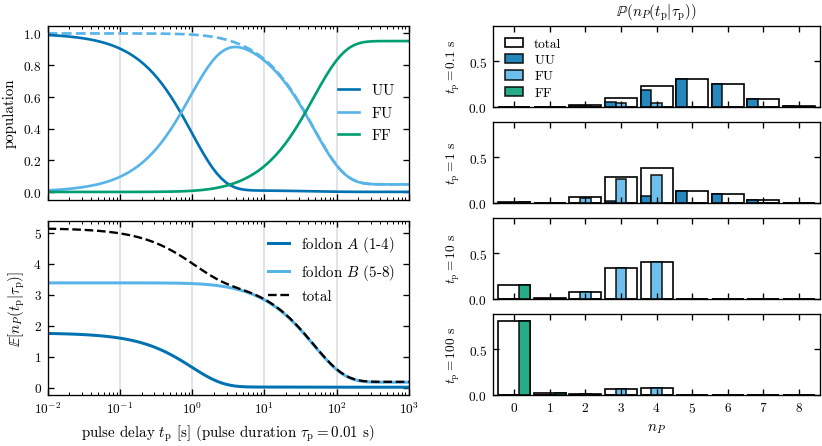

In [25]:
col_UU = COLORS['uncoupled']    #COLORS['concerted']     # red-ish (unfolded)
col_FU = COLORS['other2']        # orange (intermediate)
col_FF = COLORS['basins']        # green (folded)
col_A  = COLORS['uncoupled']     # blue (foldon A)
col_B  = COLORS['other2']        # sky blue (foldon B)

basin_plot_labels = [r'${\rm UU}$', r'${\rm FU}$', r'${\rm FF}$']
basin_cols        = [col_UU, col_FU, col_FF]

Ns = len(tQ_snaps)
fig = plt.figure(figsize=(7, 4))

gs_L = fig.add_gridspec(2, 1, hspace=0.12,
                        left=0.07, right=0.50, top=0.93, bottom=0.16)
gs_R = fig.add_gridspec(Ns, 1, hspace=0.18,
                        left=0.60, right=0.99, top=0.93, bottom=0.16)

# ---- (a) basin populations -------------------------------------------
ax_p = fig.add_subplot(gs_L[0, 0])
ax_p.semilogx(t_Q, p_tQ[:,0] + p_tQ[:, 1], color=col_FU, lw=1.6, linestyle='--')
ax_p.semilogx(t_Q, p_tQ[:, 0], color=col_UU, lw=1.6, label=basin_plot_labels[0])
ax_p.semilogx(t_Q, p_tQ[:, 1], color=col_FU, lw=1.6, label=basin_plot_labels[1])
ax_p.semilogx(t_Q, p_tQ[:, 2], color=col_FF, lw=1.6, label=basin_plot_labels[2])
#for b, c in enumerate((col_UU, col_FU, col_FF)):
    #ax_p.axhline(p_eq[b], color=c, lw=0.6, ls=':')
ax_p.set_xlim(10**-2, 10**3)
ax_p.set_ylim(-0.05, 1.05)
ax_p.set_ylabel(r'population')
ax_p.legend(loc='center right', fontsize=9, handlelength=1.4, frameon=False)
plt.setp(ax_p.get_xticklabels(), visible=False)
#ax_p.text(0.03, 0.93, 'a', transform=ax_p.transAxes,
#          fontweight='bold', va='top')
#ax_p.text(0.015, 0.40,
#          rf'$1/k_f^A={1/k_fA:.2g}$ s', fontsize=7, color=col_UU)
#ax_p.text(0.015, 0.30,
#          rf'$1/k_f^B={1/k_fB:.2g}$ s', fontsize=7, color=col_FU)

# ---- (b) per-foldon centroid at end of pulse -------------------------
ax_c = fig.add_subplot(gs_L[1, 0], sharex=ax_p)
ax_c.semilogx(t_Q, c_A,            color=col_A, lw=1.8,
              label=rf'foldon $A$ $(1$-${len(foldon_A)})$')
ax_c.semilogx(t_Q, c_B,            color=col_B, lw=1.8,
              label=rf'foldon $B$ $({len(foldon_A)+1}$-${N})$')
ax_c.semilogx(t_Q, centroid_pulse, color='black', lw=1.4, ls='--',
              label='total')
ax_c.set_xlim(t_Q[0], t_Q[-1])
ax_c.set_xlabel(r'pulse delay $t_{\rm p}$ [s] (pulse duration $\tau_{\rm p} = 0.01$ s)')
ax_c.set_ylabel(r'$\mathbb{E}[n_P(t_{\rm p}|\tau_{\rm p})]$')
ax_c.legend(loc='upper right', fontsize=9, handlelength=1.4, frameon=False)
#ax_c.text(0.03, 0.93, 'b', transform=ax_c.transAxes,
#          fontweight='bold', va='top')

# mark snapshot delays
for tq in tQ_snaps:
    for ax in (ax_p, ax_c):
        ax.axvline(tq, color='slategray', alpha=.25, lw=1, zorder=0)

# ---- (c) uptake distribution at selected delays -----------------------
kvals = np.arange(N + 1)
ymax_u = ud_snap.max() * 1.10

for ti, tq in enumerate(tQ_snaps):
    ax_u = fig.add_subplot(gs_R[ti, 0])
    p_at = p0 @ expm(L_basin * tq)
    contrib = p_at[:, None] * ud_basin_cond            # (3, N+1)
    total   = contrib.sum(axis=0)
    ymax    = max(ymax_u, total.max())

    # ---- stacked contributions ----
    bottom = np.zeros(N + 1)
    center = [-.3, 0, .3]
            # ---- total envelope outline ----
    ax_u.bar(kvals, total, width=.9,
            color='white', edgecolor='black', lw=1,
            label=r'total' if ti == 0 else None)    #  $\mathbb{P}(n_P)$
    for b in range(3):
        ax_u.bar(kvals + center[b], contrib[b], width=0.3, bottom=bottom,
               color=basin_plot_colors[b], edgecolor='black', lw=1, alpha=0.85,
               label=basin_plot_labels[b] if ti == 0 else None)
        bottom = 0#bottom + contrib[b]
        if ti == 0:
            ax_u.legend(loc='upper left', fontsize=8, frameon=False,
               handlelength=1.4, labelspacing=0.25)
            ax_u.set_title(r'$\mathbb{P}(n_P(t_{\rm p}|\tau_{\rm p}))$')
    #ax_u.bar(kvals, ud_snap[ti], width=0.9,
    #         color=col_FU, edgecolor='black', lw=0.6, alpha=0.9)
    ax_u.set_xticks(kvals)
    ax_u.set_xlim(-0.6, N + 0.6)
    ax_u.set_ylim(0, ymax_u)
    if ti != Ns - 1:
        plt.setp(ax_u.get_xticklabels(), visible=False)
    else:
        ax_u.set_xlabel(r'$n_P$')
    ax_u.set_ylabel(rf'$t_{{\rm p}}={tq:g}$ s',
                    fontsize=8)
    #if ti == 0:
        #ax_u.text(0.03, 0.94, 'c', transform=ax_u.transAxes,
        #          fontweight='bold', va='top')
        #ax_u.set_title(rf'pulse $\tau_{{\rm P}}={tau_P*1000:g}$ ms',
        #               fontsize=8)

fig.savefig(os.path.join(PLOTS_DIR, 'fig_foldons_pulsed_labeling.pdf'),
            bbox_inches='tight')
plt.show()

## Cross-check

In [27]:
from scipy.optimize import curve_fit

single = lambda t, A, B, k: A + B * np.exp(-k * t)

popt_A, _ = curve_fit(single, t_Q, c_A,
                       p0=[c_A[-1], c_A[0] - c_A[-1], k_fA])
popt_B, _ = curve_fit(single, t_Q, c_B,
                       p0=[c_B[-1], c_B[0] - c_B[-1], k_fB])

print(f'foldon A: fitted k = {popt_A[2]:.3g} /s   (truth k_f^A = {k_fA:g} /s)')
print(f'foldon B: fitted k = {popt_B[2]:.3g} /s   (truth k_f^B = {k_fB:g} /s)')
print('  (B is approximately single-exp here because k_f^B > k_f^A,'
      ' so the rate-limiting step in the cascade is A folding)')

foldon A: fitted k = 1.01 /s   (truth k_f^A = 1 /s)
foldon B: fitted k = 0.0202 /s   (truth k_f^B = 0.02 /s)
  (B is approximately single-exp here because k_f^B > k_f^A, so the rate-limiting step in the cascade is A folding)
